I want to look at the available bam's from colo 829 and HG008 which I filtered, see what tags they have, and the CpG probability distribution, and how many CpG/C (dependent on the tag) do not have a probability assigned to them

In [1]:
import os
import re
from collections import Counter
import pysam
import pandas as pd

bam_files = [
    "/data/gidb/shared/datasets/MethylBERT/HG008/normal_duodenal_tissue/HG008-N-D_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_94x_pass.bam",
    "/data/gidb/shared/datasets/MethylBERT/HG008/normal_pancreatic_tissue/HG008-N-P_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_41x_pass.bam",
    "/data/gidb/shared/datasets/MethylBERT/HG008/PDAC_tumor/HG008-T_CHM13v2.0_ONT-R10.4.1-doradov0.3.4-5mCG-5hmC_63x_UCSC_20230905_pass.bam",
    "/data/gidb/shared/datasets/MethylBERT/COLO829_BL/colo829/bam_filtered/PAU59949.d052sup4305mCG_5hmCGvHg38_pass.bam",
    "/data/gidb/shared/datasets/MethylBERT/COLO829_BL/colo829/bam_filtered/PAU61426.d052sup4305mCG_5hmCGvHg38_pass.bam",
    "/data/gidb/shared/datasets/MethylBERT/COLO829_BL/colo829bl/bam_filtered/PAU59807.d052sup4305mCG_5hmCGvHg38_pass.bam",
    "/data/gidb/shared/datasets/MethylBERT/COLO829_BL/colo829bl/bam_filtered/PAU61427.d052sup4305mCG_5hmCGvHg38_pass.bam",
]

# Decode MM tag prefix per SAM spec:
#   format: [ACGTUN][+-]([a-z]+|[0-9]+)[.?]?
#   - base+strand        e.g. C+ , G-
#   - modification code  m=5mC, h=5hmC, mh=joint, plus ChEBI numeric codes
#   - implicit marker    ? = unlisted bases have NO call (skipped by basecaller)
#                        . = unlisted bases are implicitly UNMODIFIED
#                        absent = treated as . per current spec

MOD_CODE_MEANINGS = {
    "m":  "5-methylcytosine (5mC)",
    "h":  "5-hydroxymethylcytosine (5hmC)",
    "mh": "5mC + 5hmC reported jointly",
    "f":  "5-formylcytosine (5fC)",
    "c":  "5-carboxylcytosine (5caC)",
    "a":  "N6-methyladenosine (6mA)",
    "o":  "8-oxoguanine",
}

IMPLICIT_MEANINGS = {
    "?": "no-call: unlisted bases have NO probability (basecaller skipped them)",
    ".": "implicit-zero: unlisted bases are treated as unmodified (low prob)",
    "":  "implicit-zero by default (no marker; spec default = unmodified)",
}

PREFIX_RE = re.compile(r"^([ACGTUN])([+-])([a-z]+|\d+)([.?]?)$")

In [2]:
def scan_bam_mm_tags(bam_path, n_reads=500):
    """Sample primary reads and count which MM-tag prefixes appear."""
    prefixes = Counter()
    n_with_mm = n_without_mm = n_total = 0

    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            if read.is_secondary or read.is_supplementary:
                continue
            n_total += 1

            mm = None
            for tag in ("MM", "Mm"):  # both spellings exist in the wild
                if read.has_tag(tag):
                    mm = read.get_tag(tag)
                    break

            if not mm:
                n_without_mm += 1
            else:
                n_with_mm += 1
                for entry in mm.rstrip(";").split(";"):
                    if entry:
                        prefix = entry.split(",", 1)[0]
                        prefixes[prefix] += 1

            if n_total >= n_reads:
                break

    return prefixes, n_with_mm, n_without_mm, n_total


rows = []
for bam_path in bam_files:
    sample = os.path.basename(bam_path).replace(".bam", "")
    prefixes, n_w, n_wo, n_t = scan_bam_mm_tags(bam_path, n_reads=500)

    if not prefixes:
        rows.append({
            "sample": sample, "mm_prefix": "(none)", "base+strand": "-",
            "mod_code": "-", "mod_meaning": "-", "implicit": "-",
            "implicit_meaning": "no MM tags found in sampled reads",
            "n_reads_with_prefix": 0, "n_reads_with_mm": n_w, "n_reads_sampled": n_t,
        })
        continue

    for prefix, count in prefixes.most_common():
        m = PREFIX_RE.match(prefix)
        if m:
            base, strand, mod, implicit = m.groups()
            rows.append({
                "sample": sample,
                "mm_prefix": prefix,
                "base+strand": f"{base}{strand}",
                "mod_code": mod,
                "mod_meaning": MOD_CODE_MEANINGS.get(mod, "unknown code"),
                "implicit": implicit if implicit else "(absent)",
                "implicit_meaning": IMPLICIT_MEANINGS[implicit],
                "n_reads_with_prefix": count,
                "n_reads_with_mm": n_w,
                "n_reads_sampled": n_t,
            })
        else:
            rows.append({
                "sample": sample, "mm_prefix": prefix, "base+strand": "?",
                "mod_code": "?", "mod_meaning": "could not parse",
                "implicit": "?", "implicit_meaning": "could not parse",
                "n_reads_with_prefix": count, "n_reads_with_mm": n_w,
                "n_reads_sampled": n_t,
            })

mm_inventory = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
mm_inventory

,sample,mm_prefix,base+strand,mod_code,mod_meaning,implicit,implicit_meaning,n_reads_with_prefix,n_reads_with_mm,n_reads_sampled
0,HG008-N-D_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_94x_...,C+h.,C+,h,5-hydroxymethylcytosine (5hmC),.,implicit-zero: unlisted bases are treated as unmodified ...,500,500,500
1,HG008-N-D_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_94x_...,C+m.,C+,m,5-methylcytosine (5mC),.,implicit-zero: unlisted bases are treated as unmodified ...,500,500,500
2,HG008-N-P_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_41x_...,C+h.,C+,h,5-hydroxymethylcytosine (5hmC),.,implicit-zero: unlisted bases are treated as unmodified ...,500,500,500
3,HG008-N-P_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_41x_...,C+m.,C+,m,5-methylcytosine (5mC),.,implicit-zero: unlisted bases are treated as unmodified ...,500,500,500
4,HG008-T_CHM13v2.0_ONT-R10.4.1-doradov0.3.4-5mCG-5hmC_63x...,C+h?,C+,h,5-hydroxymethylcytosine (5hmC),?,no-call: unlisted bases have NO probability (basecaller ...,500,500,500
5,HG008-T_CHM13v2.0_ONT-R10.4.1-doradov0.3.4-5mCG-5hmC_63x...,C+m?,C+,m,5-methylcytosine (5mC),?,no-call: unlisted bases have NO probability (basecaller ...,500,500,500
6,PAU59949.d052sup4305mCG_5hmCGvHg38_pass,C+h?,C+,h,5-hydroxymethylcytosine (5hmC),?,no-call: unlisted bases have NO probability (basecaller ...,500,500,500
7,PAU59949.d052sup4305mCG_5hmCGvHg38_pass,C+m?,C+,m,5-methylcytosine (5mC),?,no-call: unlisted bases have NO probability (basecaller ...,500,500,500
8,PAU61426.d052sup4305mCG_5hmCGvHg38_pass,C+h?,C+,h,5-hydroxymethylcytosine (5hmC),?,no-call: unlisted bases have NO probability (basecaller ...,500,500,500
9,PAU61426.d052sup4305mCG_5hmCGvHg38_pass,C+m?,C+,m,5-methylcytosine (5mC),?,no-call: unlisted bases have NO probability (basecaller ...,500,500,500


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

N_BUCKETS = 10
BUCKET_EDGES = np.linspace(0, 1, N_BUCKETS + 1)        # 0.0, 0.1, ..., 1.0
BUCKET_CENTERS = (BUCKET_EDGES[:-1] + BUCKET_EDGES[1:]) / 2  # 0.05, 0.15, ..., 0.95


def ml_to_bucket(ml_byte):
    """ML byte (0..255) → bucket index 0..9 for prob bins of width 0.1."""
    return min(int(ml_byte / 256.0 * N_BUCKETS), N_BUCKETS - 1)


def histogram_mod_probs(bam_path, n_reads=200):
    """Sample primary reads, return per-mod histogram of probabilities.

    Returns:
        hist: {mod_key: np.array(N_BUCKETS) of counts}, mod_key like 'C+m'
        n_calls: {mod_key: total calls}
        n_sampled: number of primary reads actually examined
    """
    hist = defaultdict(lambda: np.zeros(N_BUCKETS, dtype=np.int64))
    n_calls = defaultdict(int)
    n_sampled = 0

    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            if read.is_secondary or read.is_supplementary:
                continue
            n_sampled += 1

            # pysam parses MM/ML for us. Returns dict:
            #   (canonical_base, strand, mod_code) -> [(query_pos, ML_byte), ...]
            # strand: 0 = forward, 1 = reverse;  mod_code: 'm', 'h', or int (ChEBI)
            mods = read.modified_bases
            if mods:
                for (canon, _strand, mod), calls in mods.items():
                    key = f"{canon}+{mod}"  # e.g. 'C+m', 'C+h'
                    for _pos, ml in calls:
                        hist[key][ml_to_bucket(ml)] += 1
                        n_calls[key] += 1

            if n_sampled >= n_reads:
                break

    return dict(hist), dict(n_calls), n_sampled


N_READS_PER_BAM = 200
prob_distributions = {}

for bam_path in bam_files:
    print(f"Scanning {os.path.basename(bam_path)}")
    h, n, ns = histogram_mod_probs(bam_path, n_reads=N_READS_PER_BAM)
    prob_distributions[bam_path] = (h, n, ns)
    for key, count in sorted(n.items()):
        print(f"   {key}: {count:>10,} calls across {ns} reads "
              f"(~{count/ns:>5,.0f} per read)")

Scanning HG008-N-D_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_94x_pass.bam
   C+h:    184,532 calls across 200 reads (~  923 per read)
   C+m:    184,532 calls across 200 reads (~  923 per read)
Scanning HG008-N-P_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_41x_pass.bam
   C+h:    479,522 calls across 200 reads (~2,398 per read)
   C+m:    479,522 calls across 200 reads (~2,398 per read)
Scanning HG008-T_CHM13v2.0_ONT-R10.4.1-doradov0.3.4-5mCG-5hmC_63x_UCSC_20230905_pass.bam
   C+h:     71,379 calls across 200 reads (~  357 per read)
   C+m:     71,379 calls across 200 reads (~  357 per read)
Scanning PAU59949.d052sup4305mCG_5hmCGvHg38_pass.bam
   C+h:     57,124 calls across 200 reads (~  286 per read)
   C+m:     57,124 calls across 200 reads (~  286 per read)
Scanning PAU61426.d052sup4305mCG_5hmCGvHg38_pass.bam
   C+h:     56,249 calls across 200 reads (~  281 per read)
   C+m:     56,249 calls across 200 reads (~  281 per read)
Scanning PAU59807.d052sup4305mCG_5hmCGvHg38_pass.bam
   C

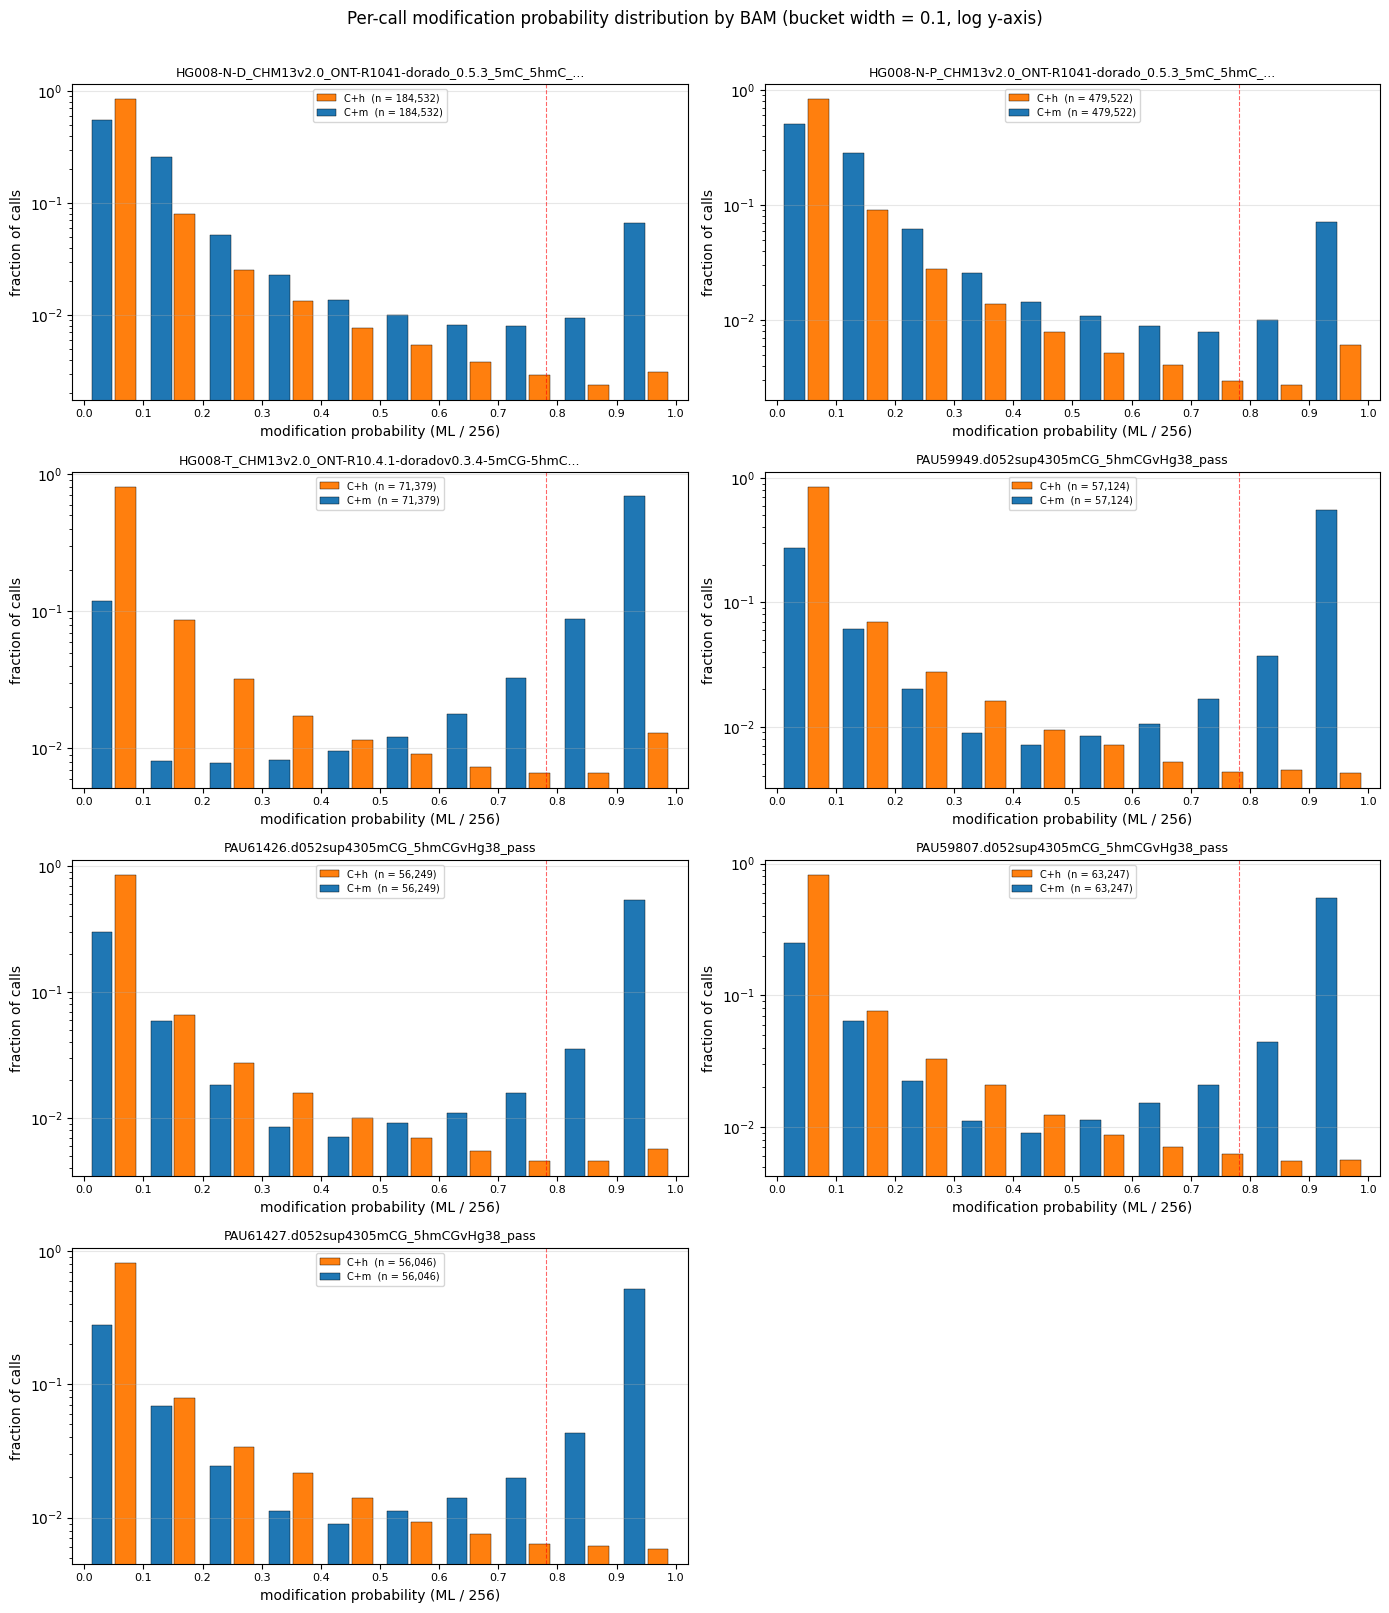

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

mod_colors = {"C+m": "tab:blue", "C+h": "tab:orange"}
mod_offsets = {"C+m": -0.02, "C+h": +0.02}
bar_width = 0.035

for ax, (bam_path, (hist, ncalls, nreads)) in zip(axes, prob_distributions.items()):
    short_name = os.path.basename(bam_path).replace(".bam", "")
    if len(short_name) > 55:
        short_name = short_name[:52] + "..."

    for key in sorted(hist.keys()):
        counts = hist[key]
        total = ncalls[key]
        frac = counts / total if total > 0 else counts
        ax.bar(BUCKET_CENTERS + mod_offsets.get(key, 0),
               frac,
               width=bar_width,
               color=mod_colors.get(key, "gray"),
               label=f"{key}  (n = {total:,})",
               edgecolor="black",
               linewidth=0.3)

    # Reference line at ML=200/256 ≈ 0.78 — the conventional high-confidence cutoff
    ax.axvline(200/256, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.set_title(short_name, fontsize=9)
    ax.set_xlabel("modification probability (ML / 256)")
    ax.set_ylabel("fraction of calls")
    ax.set_yscale("log")
    ax.set_xticks(BUCKET_EDGES)
    ax.set_xticklabels([f"{x:.1f}" for x in BUCKET_EDGES], fontsize=8)
    ax.set_xlim(-0.02, 1.02)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=7, loc="upper center")

# Hide the unused 8th subplot
for ax in axes[len(prob_distributions):]:
    ax.axis("off")

plt.suptitle("Per-call modification probability distribution by BAM "
             "(bucket width = 0.1, log y-axis)",
             fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

In [5]:
def count_listed_vs_unlisted(bam_path, n_reads=200):
    """For each sampled primary read:
       - count Cs in the read sequence
       - count CpGs (C followed by G) in the read sequence
       - count Cs that have a 5mC call (i.e. appear in MM/ML for C+m)
       Aggregate across reads.

    Note: the read sequence in BAM is in *sequenced* orientation. The MM tag
    refers to that same orientation. For nanopore, reads are not reverse-
    complemented on output, so we just walk read.query_sequence directly.
    """
    total_C = 0
    total_CpG = 0
    total_listed_C_for_m = 0   # Cs that received a 5mC probability
    total_listed_C_for_h = 0   # Cs that received a 5hmC probability
    n_sampled = 0
    n_no_seq = 0

    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            if read.is_secondary or read.is_supplementary:
                continue
            n_sampled += 1

            seq = read.query_sequence
            if seq is None:
                n_no_seq += 1
                if n_sampled >= n_reads:
                    break
                continue

            # Count Cs and CpGs in the read sequence
            n_C = seq.count("C")
            # CpG = "CG" dinucleotide; counting overlap-free is fine here
            # (CG can't overlap with itself anyway)
            n_CpG = 0
            for i in range(len(seq) - 1):
                if seq[i] == "C" and seq[i+1] == "G":
                    n_CpG += 1

            total_C += n_C
            total_CpG += n_CpG

            # How many Cs got a probability for each modification?
            mods = read.modified_bases
            if mods:
                for (canon, _strand, mod), calls in mods.items():
                    if canon != "C":
                        continue
                    if mod == "m":
                        total_listed_C_for_m += len(calls)
                    elif mod == "h":
                        total_listed_C_for_h += len(calls)

            if n_sampled >= n_reads:
                break

    return {
        "n_reads": n_sampled,
        "n_reads_no_seq": n_no_seq,
        "total_C_in_seq": total_C,
        "total_CpG_in_seq": total_CpG,
        "total_C_with_5mC_call": total_listed_C_for_m,
        "total_C_with_5hmC_call": total_listed_C_for_h,
    }


coverage_rows = []
for bam_path in bam_files:
    sample = os.path.basename(bam_path).replace(".bam", "")
    print(f"Scanning {sample}")
    r = count_listed_vs_unlisted(bam_path, n_reads=200)

    # Decide whether to compare against C or CpG denominator based on
    # which implicit marker the BAM uses. We already know from cell 2,
    # but re-derive here from a single read to keep the cell self-contained.
    implicit_marker = None
    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            if read.is_secondary or read.is_supplementary:
                continue
            mm = read.get_tag("MM") if read.has_tag("MM") else (
                 read.get_tag("Mm") if read.has_tag("Mm") else "")
            if mm:
                first_entry_prefix = mm.split(";", 1)[0].split(",", 1)[0]
                m = PREFIX_RE.match(first_entry_prefix)
                if m:
                    implicit_marker = m.group(4) or "(absent)"
                break

    if implicit_marker == ".":
        # All Cs assessed. Denominator = total Cs in sequence.
        denom = r["total_C_in_seq"]
        denom_label = "Cs in read"
        unassessed_5mC = denom - r["total_C_with_5mC_call"]
        unassessed_5hmC = denom - r["total_C_with_5hmC_call"]
    else:  # '?' or absent — CpG-only mode in your data
        # Only CpG-context Cs assessed. Denominator = total CpGs in sequence.
        denom = r["total_CpG_in_seq"]
        denom_label = "CpGs in read"
        unassessed_5mC = denom - r["total_C_with_5mC_call"]
        unassessed_5hmC = denom - r["total_C_with_5hmC_call"]

    coverage_rows.append({
        "sample": sample,
        "implicit": implicit_marker,
        "denominator": denom_label,
        "n_reads": r["n_reads"],
        "total_C_in_seq": r["total_C_in_seq"],
        "total_CpG_in_seq": r["total_CpG_in_seq"],
        "n_C_with_5mC_call": r["total_C_with_5mC_call"],
        "n_C_without_5mC_call": unassessed_5mC,
        "pct_unassessed_5mC": 100 * unassessed_5mC / denom if denom else float("nan"),
        "n_C_with_5hmC_call": r["total_C_with_5hmC_call"],
        "n_C_without_5hmC_call": unassessed_5hmC,
        "pct_unassessed_5hmC": 100 * unassessed_5hmC / denom if denom else float("nan"),
    })

coverage_df = pd.DataFrame(coverage_rows)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
coverage_df

Scanning HG008-N-D_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_94x_pass
Scanning HG008-N-P_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_41x_pass
Scanning HG008-T_CHM13v2.0_ONT-R10.4.1-doradov0.3.4-5mCG-5hmC_63x_UCSC_20230905_pass
Scanning PAU59949.d052sup4305mCG_5hmCGvHg38_pass
Scanning PAU61426.d052sup4305mCG_5hmCGvHg38_pass
Scanning PAU59807.d052sup4305mCG_5hmCGvHg38_pass
Scanning PAU61427.d052sup4305mCG_5hmCGvHg38_pass


,sample,implicit,denominator,n_reads,total_C_in_seq,total_CpG_in_seq,n_C_with_5mC_call,n_C_without_5mC_call,pct_unassessed_5mC,n_C_with_5hmC_call,n_C_without_5hmC_call,pct_unassessed_5hmC
0,HG008-N-D_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_94x_...,.,Cs in read,200,404530,18466,184532,219998,54.384,184532,219998,54.384
1,HG008-N-P_CHM13v2.0_ONT-R1041-dorado_0.5.3_5mC_5hmC_41x_...,.,Cs in read,200,812282,44637,479522,332760,40.966,479522,332760,40.966
2,HG008-T_CHM13v2.0_ONT-R10.4.1-doradov0.3.4-5mCG-5hmC_63x...,?,CpGs in read,200,1247468,71379,71379,0,0.000,71379,0,0.000
3,PAU59949.d052sup4305mCG_5hmCGvHg38_pass,?,CpGs in read,200,956475,57124,57124,0,0.000,57124,0,0.000
4,PAU61426.d052sup4305mCG_5hmCGvHg38_pass,?,CpGs in read,200,957006,56249,56249,0,0.000,56249,0,0.000
5,PAU59807.d052sup4305mCG_5hmCGvHg38_pass,?,CpGs in read,200,1005192,63247,63247,0,0.000,63247,0,0.000
6,PAU61427.d052sup4305mCG_5hmCGvHg38_pass,?,CpGs in read,200,944685,56046,56046,0,0.000,56046,0,0.000
